<a href="https://colab.research.google.com/github/OmaRecalde/machinelearning2026/blob/main/Ejercicio_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Programa 12: Regresión OLS (Ordinary Least Squares)

Omar Recalde
Github:

In [10]:
import numpy as np
from math import sqrt
from pprint import pprint
import matplotlib.pyplot as plt
import pandas as pd

from sklearn import datasets, linear_model, metrics, preprocessing
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import (
    cross_validate,
    KFold,
    cross_val_predict,
    train_test_split,
    cross_val_score
)
from sklearn.metrics import make_scorer, mean_squared_error

## Carga de datos

In [8]:
# Carga de datos
# Nota: load_boston() ha sido eliminado en versiones recientes de scikit-learn.
# La descarga de fetch_california_housing() falló, por lo que cargaremos desde archivos CSV locales.

# Cargar los datasets de entrenamiento y prueba
df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test = pd.read_csv('/content/sample_data/california_housing_test.csv')

# Combinar los datasets
datos_df = pd.concat([df_train, df_test], ignore_index=True)

# Separar las características (X) y la variable objetivo (y)
X = datos_df.drop('median_house_value', axis=1).values
y = datos_df['median_house_value'].values

print('Dimensiones de X: ', np.shape(X))

Dimensiones de X:  (20000, 8)


In [9]:
# Check for missing values in the dataset
missing_values = datos_df.isnull().sum()
print("Missing values per column:")
print(missing_values)

Missing values per column:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
dtype: int64


## Métricas de evaluación

In [12]:
metricas = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': make_scorer(
        lambda y_true, y_pred: sqrt(metrics.mean_squared_error(y_true, y_pred)),
        greater_is_better=False
    ),
    'MAPE': make_scorer(
        lambda y_true, y_pred: np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        greater_is_better=False
    ),
    'R2': 'r2'
}

### 1) Partición de datos externa

In [13]:
X_training, X_testing, y_training, y_testing = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Dimensiones X_training:", np.shape(X_training))

Dimensiones X_training: (16000, 8)


### 2) Extracción de características
### 3) Selección de atributos
### 4) Estandarización de los datos de entrenamiento

In [14]:
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_training)
X_stdr = stdr_trained.transform(X_training)

### 5) Construcción del algoritmo de aprendizaje
#### 5.1) Validación cruzada interna
Extraer directamente resultados del error para cada partición (fold), en lugar de las predicciones.

In [15]:
reg = linear_model.LinearRegression(fit_intercept=True)

cross_val_results = cross_validate(
    reg,
    X_stdr,
    y_training,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring=metricas
)

# print("cross_val_MAE: %0.4f +/- %0.4f" % (-cross_val_results['test_MAE'].mean(), cross_val_results['test_MAE'].std()))
pprint(cross_val_results)

{'fit_time': array([0.06120491, 0.0182941 , 0.01680374, 0.02045441, 0.02362657]),
 'score_time': array([0.00868464, 0.00809193, 0.00990844, 0.00778627, 0.00519514]),
 'test_MAE': array([-50547.83751395, -50348.0783369 , -51000.81555342, -50729.27065027,
       -51830.41565277]),
 'test_MAPE': array([-29.62057321, -30.45297059, -30.13691102, -30.41870361,
       -31.0843116 ]),
 'test_R2': array([0.60488118, 0.65019056, 0.63850752, 0.63895574, 0.63986869]),
 'test_RMSE': array([-71418.24196819, -67896.73302959, -69465.81903535, -68817.4723656 ,
       -70321.47920864])}


#### 5.2) Entrenamiento con todos los datos para obtener los coeficientes del modelo

In [16]:
model = reg.fit(X_stdr, y_training)

# Obtención de los coeficientes del modelo
w = model.coef_
print('Model coefficients:\n', w)

# Obtención del término independiente del modelo
w_0 = model.intercept_
print('\nTérmino independiente: ', w_0)

Model coefficients:
 [-86993.34064811 -91297.78260689  14599.08272979 -18675.94889251
  48271.16848224 -41661.03176032  16928.44006723  76378.4895335 ]

Término independiente:  207173.59656250293


# PREDICCIÓN
### 6) Extracción de las características de test
### 7) Selección de los atributos de test
### 8) Estandarización de las características de test

In [17]:
X_test_stdr = stdr_trained.transform(X_testing)

### 9) Predicción del conjunto de test

In [18]:
y_pred_test = model.predict(X_test_stdr)

### Cálculo de las métricas de evaluación

In [19]:
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = np.sqrt(MSE)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE:  %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2:   %.4f' % R2)

MAE:  50564.3587
MSE:  4869758532.5198
RMSE: 69783.6552
MAPE: 0.3020
R2:   0.6453


### Gráfica de realidad vs. predicción

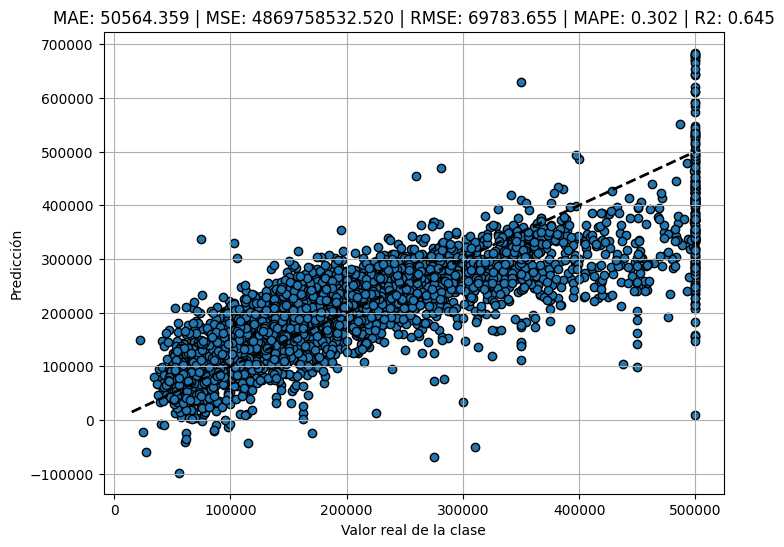

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_testing, y_pred_test, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f | MSE: %.3f | RMSE: %.3f | MAPE: %.3f | R2: %.3f" % (MAE, MSE, RMSE, MAPE, R2))
plt.grid(True)
plt.show()

## Exportación a HTML

In [21]:
# 1. Si estás en Google Colab:
# Guarda el cuaderno primero (Ctrl+S / Cmd+S), luego ejecuta:
import os

# Reemplaza 'nombre_del_cuaderno.ipynb' por el nombre exacto de tu archivo si lo descargaste o renombraste:
!jupyter nbconvert --to html "/content/*.ipynb" --output-dir="/content/export/"

print("Archivo HTML generado en /content/export/. Descárgalo, ábrelo en el navegador y pulsa Ctrl+P / Cmd+P para guardar como PDF.")

[NbConvertApp] WARNING | pattern '/content/*.ipynb' matched no files
[NbConvertApp] Making directory /content/export/
This application is used to convert notebook files (*.ipynb)
        to various other formats.


Options
The options below are convenience aliases to configurable class-options,
as listed in the "Equivalent to" description-line of the aliases.
To see all configurable class-options for some <cmd>, use:
    <cmd> --help-all

--debug
    set log level to logging.DEBUG (maximize logging output)
    Equivalent to: [--Application.log_level=10]
--show-config
    Show the application's configuration (human-readable format)
    Equivalent to: [--Application.show_config=True]
--show-config-json
    Show the application's configuration (json format)
    Equivalent to: [--Application.show_config_json=True]
--generate-config
    generate default config file
    Equivalent to: [--JupyterApp.generate_config=True]
-y
    Answer yes to any questions instead of prompting.
    Equivalent 